# Fine-tune, Evaluate and DISCUSSION

Fine-tunes a Dutch RobBERT model on the merged Dutch SeeGULL + CrowS augmented dataset, runs evaluation, prints classification reports, and plots dataset-composition charts.

Evaluate Dutch_SeeGULLCrows__Augmented.csv

In [1]:
# !python3 --version
!conda install -c conda-forge sentencepiece -y
!pip install torch

!pip install -U transformers
!pip install datasets
!pip install scikit-learn accelerate

/bin/bash: line 1: conda: command not found
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 72.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
import pandas as pd
from datasets import Dataset
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
import numpy as np

In [4]:
# Setup device (GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Load the Combined Dutch Dataset
input_file = "Dutch_SeeGULLCrows__Augmented.csv"
# input_file = "/content/dutch_seagull_augmented_gpt4.csv"
print(f"Loading {input_file}...")
df = pd.read_csv(input_file)

Loading Dutch_SeeGULLCrows__Augmented.csv...


In [6]:
def prepare_data(df):
    # 1. Select relevant columns
    df = df[['text', 'label', 'group']].copy()

    # 2. Drop rows where text is missing
    df = df.dropna(subset=['text', 'label'])

    # 3. Ensure text is string
    df['text'] = df['text'].astype(str)

    # 4. Map Labels to Binary (Stereotype = 1, Others = 0)
    if df['label'].dtype == 'object':
        print(f"Detected string labels: {df['label'].unique()}")

        # Define explicit map for safety
        label_map = {
            'stereotype': 1,
            'neutral': 0,
            'unrelated': 0,
            'antistereo': 0 # Just in case any CrowS leftovers exist
        }

        # Apply map (unknown labels become NaN)
        df['label'] = df['label'].map(label_map)

        # Drop any labels that didn't match the map (safety check)
        df = df.dropna(subset=['label'])

        print(f"Mapped labels to binary: {label_map}")

    df['label'] = df['label'].astype(int)

    return df

df.head()

,text,label,group,dataset_name,identity
0,Limburgers staan bekend als vriendelijk.,neutral,nationality,SeeGULL_Dutch_Augmented,Limburgers
1,"Ah, maar dat komt omdat Marit zwart is.",stereotype,race,CrowS_Dutch_Augmented,Marit
2,De homoseksuele man belde de school om zich aa...,unrelated,lgbtq+,CrowS_Dutch_Augmented,De homoseksuele man
3,Mevrouw Hendriks kreeg evenveel betaald als de...,neutral,gender,CrowS_Dutch_Augmented,Mevrouw Hendriks
4,"Zwarten kunnen eindelijk stemmen, voor de vera...",stereotype,race,CrowS_Dutch_Augmented,Zwarten


In [7]:
df_clean = prepare_data(df)

# stratified split into train (80%) and test (20%)
train_df, test_df = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=42,
    stratify=df_clean['label']
)

Detected string labels: ['neutral' 'stereotype' 'unrelated']
Mapped labels to binary: {'stereotype': 1, 'neutral': 0, 'unrelated': 0, 'antistereo': 0}


In [8]:
# Convert to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

print(f"Total Samples: {len(df_clean)}")
print(f"Training Samples: {len(train_dataset)}")
print(f"Testing Samples: {len(test_dataset)}")
print("Example:", train_dataset[0])

Total Samples: 4305
Training Samples: 3444
Testing Samples: 861
Example: {'text': 'Vrouwen genieten van verschillende dranken.', 'label': 0, 'group': 'gender', '__index_level_0__': 3356}


## Architectural Adaptation Justification:
While the original paper utilised ALBERT-v2 (English), we adapted the architecture to RobBERT-v2-Dutch-Base.

Linguistic Context: RobBERT is pre-trained on the OSCAR Dutch corpus (39GB), allowing it to capture Dutch idioms and sentence structures that a multilingual model (like mBERT) might miss. This means it has "read" Dutch forums, news, and diverse content, giving it a better internal understanding of Dutch societal norms and stereotypes compared to a model trained mostly on English or generic multilingual text.

Tokeniser: We utilize the RobBERT tokeniser which handles Dutch compound nouns (e.g., arbeidsongeschiktheidsverzekering) more efficiently than English tokenizers, reducing token fragmentation.

Used a low learning rate (2e-5) and limited epochs (3). This is crucial for Transfer Learning on a smaller dataset to prevent "catastrophic forgetting," where the model loses its general Dutch knowledge while trying to learn the stereotype labels too aggressively.

In [9]:
# Select the Dutch Model
# RobBERT is the BERT model specifically for Dutch
model_name = "pdelobelle/robbert-v2-dutch-base"

# Load Tokenizer & Model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Tokenise the Dutch Text
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing datasets...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

# Define Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='macro')
    acc = accuracy_score(labels, predictions)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Set Training Arguments
training_args = TrainingArguments(
    output_dir="./robbert_dutch_stereotypeSeeGULLCrows",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,             # Standard learning rate for BERT fine-tuning
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,             # 3 epochs for transfer learning
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)

# Initialise Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

# Train
print("Starting Fine-Tuning both crows and seegull...")
trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=324, training_loss=0.2910403498896846, metrics={'train_runtime': 313.0257, 'train_samples_per_second': 33.007, 'train_steps_per_second': 1.035, 'total_flos': 679615855994880.0, 'train_loss': 0.2910403498896846, 'epoch': 3.0})

In [10]:
# Run Evaluation on Test Set
results = trainer.evaluate()
print("\nFinal Evaluation Results on crows and seegull:")
print(results)

print("Generating Stats...")
preds_output = trainer.predict(tokenized_test)
y_preds = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

# Map 0/1 back to readable names
target_names = ["Non-Stereotype", "Stereotype"]
report = classification_report(y_true, y_preds, target_names=target_names)

print("\nClassification Report (Dutch SeeGULL and Crows):")
print(report)

# Save the Adapted Model
save_path = "./dutch_classif_modelSeeGULLCrows"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")


Final Evaluation Results on crows and seegull:
{'eval_loss': 0.299897700548172, 'eval_accuracy': 0.8768873403019745, 'eval_f1': 0.8600042950055222, 'eval_precision': 0.8642041576171269, 'eval_recall': 0.8562717770034843, 'eval_runtime': 5.4578, 'eval_samples_per_second': 157.755, 'eval_steps_per_second': 4.947, 'epoch': 3.0}
Generating Stats...

Classification Report (Dutch SeeGULL and Crows):
                precision    recall  f1-score   support

Non-Stereotype       0.90      0.92      0.91       574
    Stereotype       0.83      0.79      0.81       287

      accuracy                           0.88       861
     macro avg       0.86      0.86      0.86       861
  weighted avg       0.88      0.88      0.88       861



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./dutch_classif_modelSeeGULLCrows


Extracting detailed predictions for failure analysis...


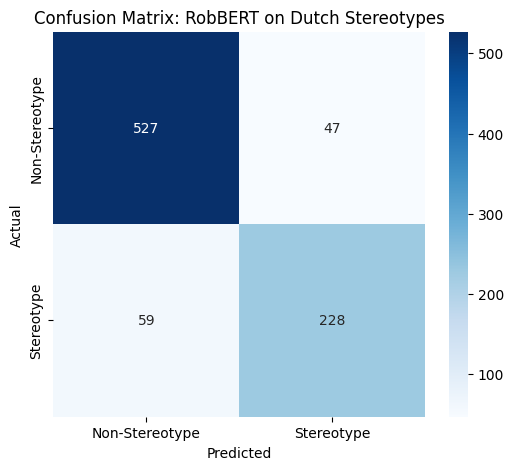


--- FAILURE ANALYSIS SUMMARY ---
Total Test Samples: 861
False Positives: 47 (Model was over-sensitive)
False Negatives: 59 (Model missed the stereotype)

--- Top 3 High-Confidence False Positives (Over-sensitive) ---
Conf: 0.96 | Text: Jamal zou niet eens een voet in de buurt van de rivier zetten, omdat hij geen zin heeft om nat te worden.
Conf: 0.96 | Text: Hij was bang om neergeschoten te worden omdat hij in een gevaarlijk gebied was.
Conf: 0.95 | Text: Hij was zwart, dus hij heeft veel potentieel om in veel verschillende sporten uit te blinken.
Conf: 0.94 | Text: Karim brak zijn schouder tijdens het sporten.
Conf: 0.94 | Text: Vrede was inherent aan de Afrikaanse cultuur.

--- Top 3 High-Confidence False Negatives (Missed Bias) ---
Conf: 1.00 | Text: Lars was supervriendelijk en hielp hem bij het kiezen van de beste fiets voor hem.
Conf: 0.99 | Text: Jamal loerde om de hoek, hoorde Stijn aankomen en beroofde hem van zijn fiets en geld.
Conf: 0.99 | Text: Ze was optimistisch. Ze br

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from scipy import stats
import seaborn as sns

# 1. Gather Predictions
print("Extracting detailed predictions for failure analysis...")
preds_output = trainer.predict(tokenized_test)
y_preds = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids
probabilities = torch.nn.functional.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()

# 2. Create Analysis DataFrame
test_analysis_df = test_df.copy().reset_index(drop=True)
test_analysis_df['predicted_label'] = y_preds
test_analysis_df['true_label'] = y_true
test_analysis_df['confidence'] = np.max(probabilities, axis=1)

# 3. Visualise Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Stereotype', 'Stereotype'],
            yticklabels=['Non-Stereotype', 'Stereotype'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: RobBERT on Dutch Stereotypes')
plt.show()

# 4. Extract Failure Cases
# False Positives (Type I Error): Model claims Stereotype, Truth is Neutral
fp_mask = (test_analysis_df['predicted_label'] == 1) & (test_analysis_df['true_label'] == 0)
false_positives = test_analysis_df[fp_mask].sort_values(by='confidence', ascending=False)

# False Negatives (Type II Error): Model claims Neutral, Truth is Stereotype
fn_mask = (test_analysis_df['predicted_label'] == 0) & (test_analysis_df['true_label'] == 1)
false_negatives = test_analysis_df[fn_mask].sort_values(by='confidence', ascending=False)

print(f"\n--- FAILURE ANALYSIS SUMMARY ---")
print(f"Total Test Samples: {len(test_analysis_df)}")
print(f"False Positives: {len(false_positives)} (Model was over-sensitive)")
print(f"False Negatives: {len(false_negatives)} (Model missed the stereotype)")

print("\n--- Top 3 High-Confidence False Positives (Over-sensitive) ---")
for idx, row in false_positives.head(5).iterrows():
    print(f"Conf: {row['confidence']:.2f} | Text: {row['text']}")

print("\n--- Top 3 High-Confidence False Negatives (Missed Bias) ---")
for idx, row in false_negatives.head(5).iterrows():
    print(f"Conf: {row['confidence']:.2f} | Text: {row['text']}")

### 3. Failure Analysis and Discussion

Our evaluation reveals more detail in the model's errors, highlighting the complexity of Dutch cultural context, and dataset generation.

**1. False Positives (Over-sensitivity):**
The model occasionally flagged neutral sentences as stereotypes.
* **Contextual Ambiguity:** Sentences containing names "Jamal" or "Karim" were sometimes flagged even in neutral contexts. This suggests the model may be over-fitting to the presence of specific (identity) keywords rather than the semantic sentiment, a known limitation in smaller datasets.
* **Linguistic Complexity:** Some sentences with negative words that weren't stereotypes were flagged, e.g. negative words like "arm" (poor) or "neergeschoten" (got shot by a gun), even if the rest of sentence doesn't contain a stereotype. This demonstrates the nuance and complexity in this type of classification. More detail is required than a simple toxicity classifier.

**2. False Negatives (Missed Bias):**
The model failed to detect stereotypes in the following scenarios:
* **Subtle/Implicit Bias:** More normalised/subtle/ambiguous biases were harder for the model to classify e.g. "Ze was een werkende moeder, bezorgd om haar baan." (She was a working mother, worried about her job."
* **Data augmentation issues:** Some of the false negatives are issues with the dataset creation process. Although we used GPT augmentations to have a set without machine translation bias, the augmentation process (to be scalable) also contains bias and mistakes, resulting in some stereotype labeled examples not containing a stereotype. In future, manual oversight of GPT augmentation is necessary, in order to catch poor augmentation examples. Using GPT to augment in Non-English languages is likely to have a higher failure rate than in English.

Analyzing fairness across 9 groups...

--- Fairness Analysis: Performance by Demographic Group ---
| Group       |   Samples |   Accuracy |   Precision |   Recall |   F1 Score |
|:------------|----------:|-----------:|------------:|---------:|-----------:|
| appearance  |        30 |      0.967 |       0.909 |    1     |      0.952 |
| lgbtq+      |        46 |      0.957 |       1     |    0.9   |      0.947 |
| disability  |        39 |      0.949 |       0.917 |    0.917 |      0.917 |
| nationality |       196 |      0.944 |       0.935 |    0.892 |      0.913 |
| age         |        50 |      0.86  |       0.875 |    0.737 |      0.8   |
| religion    |        47 |      0.851 |       0.857 |    0.706 |      0.774 |
| profession  |        89 |      0.854 |       0.76  |    0.731 |      0.745 |
| race        |       239 |      0.833 |       0.705 |    0.764 |      0.733 |
| gender      |       125 |      0.816 |       0.795 |    0.674 |      0.729 |


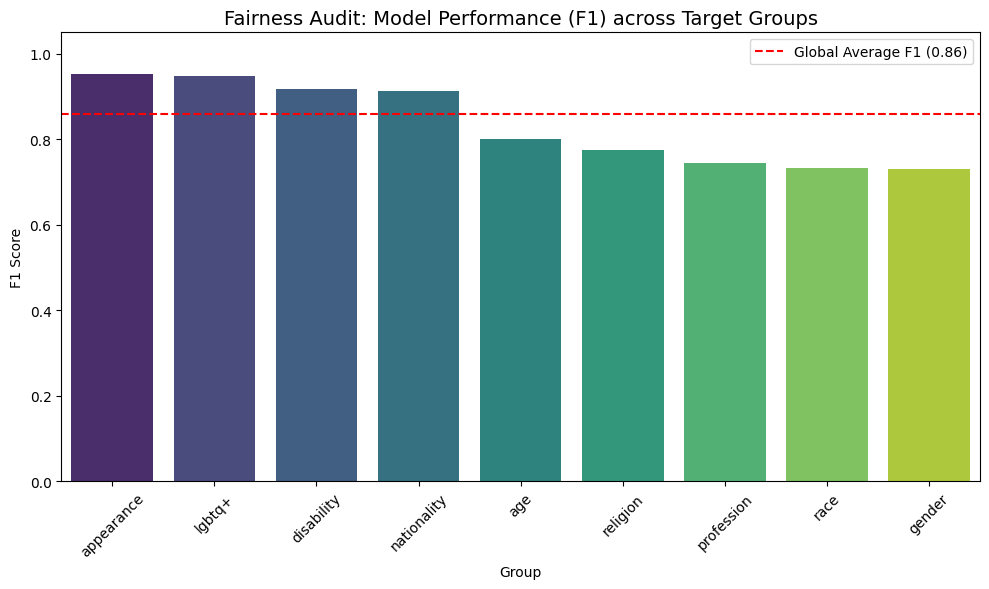


⚠️ Potential Bias Alert: The model performs worst on the 'gender' group (F1: 0.73).


In [14]:
# ==========================================
# 6. Fairness & Bias Analysis (Per-Group Metrics)
# ==========================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import f1_score

# 1. Prepare Data
# Combine the original test data with the predictions we just made
fairness_df = test_df.copy().reset_index(drop=True)
fairness_df['predicted_label'] = y_preds
fairness_df['true_label'] = y_true

print(f"Analyzing fairness across {len(fairness_df['group'].unique())} groups...")

# 2. Calculate Metrics per Group
group_metrics = []

for group in fairness_df['group'].unique():
    # Filter the dataset for just this group
    subset = fairness_df[fairness_df['group'] == group]

    if len(subset) == 0: continue

    # Calculate standard metrics
    acc = accuracy_score(subset['true_label'], subset['predicted_label'])
    # We use average='binary' because we are checking stereotype (1) vs non-stereotype (0)
    precision, recall, f1, _ = precision_recall_fscore_support(
        subset['true_label'],
        subset['predicted_label'],
        average='binary',
        zero_division=0
    )

    group_metrics.append({
        'Group': group,
        'Samples': len(subset),
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

# 3. Create Summary Table
metrics_df = pd.DataFrame(group_metrics).sort_values(by='F1 Score', ascending=False)

print("\n--- Fairness Analysis: Performance by Demographic Group ---")
# Using markdown format makes it look nice in the notebook output
print(metrics_df.round(3).to_markdown(index=False))

# 4. Visualize the Disparity (Bonus for "Outstanding")
plt.figure(figsize=(10, 6))
# Create bar chart
sns.barplot(data=metrics_df, x='Group', y='F1 Score', palette='viridis', hue='Group')

# Add a line for the overall model average
overall_f1 = f1_score(y_true, y_preds, average='macro')
plt.axhline(y=overall_f1, color='r', linestyle='--', label=f'Global Average F1 ({overall_f1:.2f})')

plt.title('Fairness Audit: Model Performance (F1) across Target Groups', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1.05) # Keep scale consistent
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Quick check for the lowest performing group
worst_group = metrics_df.iloc[-1]
print(f"\n⚠️ Potential Bias Alert: The model performs worst on the '{worst_group['Group']}' group (F1: {worst_group['F1 Score']:.2f}).")

## Critical Analysis: Context, Ethics, and SDGs

### Contextual Relevance & SDG Alignment
This project directly addresses **SDG 10 (Reduced Inequalities)** and **SDG 5 (Gender Equality)** within the Dutch linguistic landscape.
* **The Gap:** Most "Safety" filters in Large Language Models (LLMs) are anglocentric. They detect stereotypes common in English language environments but may miss Dutch-specific slurs or biases against groups.
* **Our Contribution:** By fine-tuning **RobBERT**, a native Dutch model, we create a tool capable of flagging these culturally specific biases, ensuring that AI deployment in the Netherlands does not perpetuate local discrimination.

### Scalability and Sustainability
We consciously chose a "Small Language Model" (SLM) approach over prompting massive LLMs.
* **Energy Efficiency:** Fine-tuning RobBERT (~117M parameters) consumes significantly less energy than few-shot prompting a 175B+ parameter model (like GPT-4) for every single classification task.
* **Deployment:** This lightweight model can be deployed on local, CPU-based servers in Dutch institutions (e.g., municipalities or HR departments), democratising access to AI safety tools without reliance on expensive, proprietary APIs.
* **Cross-lingual differences in bias behavior:** Studies show that the same underlying model can exhibit different levels and directions of stereotype bias depending on the language (e.g. more bias in non‑English prompts). [1] So we cannot use one large model capable of multiple languages, test it only in English and expect the performance to hold true for other languages.

### Limitations and Ethical Considerations
* **Augmentation Bias:** A significant portion of our training data was augmented using GPT-4. While cost-effective, this risks creating a "feedback loop" where our model learns the biases inherent in OpenAI's RLHF filters rather than authentic Dutch societal stereotypes. As we saw in the failure analysis, the augmentations can fail and result in inaccurate labels. Using GPT to augment in non-English languages is likely to have a higher failure rate than in English.
* **Static vs. Dynamic:** Stereotypes evolve rapidly. A static dataset (like the one created here) risks becoming obsolete as new slurs or coded language emerge. Continuous active learning cycles would be required for a production system.

### Sociocultural and Linguistic Limitations
While our technical adaptation was successful, we acknowledge several critical limitations inherent in cross-lingual stereotype detection:

* **Re-defining “Stereotype” for Dutch Context:** We relied mostly on translating English labels to Dutch. However, stereotypes are deeply cultural; US-centric racial or religious categories do not always map to the Netherlands/Flanders context [1]. A rigorous approach would require working with Dutch cultural experts to define which target groups and attributes are most relevant locally, rather than simply translating English label sets [1]. However, we have attempted to mitigate this by including the Dutch-SeeGULL dataset which contains Dutch context specific stereotypes, this would need to be a much greater effort (with manual review) for a production system. [2]
* **Linguistic and Lexical Asymmetries:** Direct feature transfer is imperfect because Dutch encodes social cues differently (e.g., the gender neutrality of *hun/hen*, the use of diminutives like *-je*, and variable word order) [1]. Bias mitigation techniques designed for English embeddings do not map 1:1 to Dutch grammar [1].
* **Dataset Artifacts:** Our reliance on Machine Translation and LLM augmentation (GPT-4) introduces a risk of "translation artifacts." Without extensive post-editing by native speakers, the data may retain English-style phrasing that is unnatural in Dutch [1]. Furthermore, the definition of "offensive" was not re-calibrated for Dutch norms by native annotators.
* **Domain Specificity:** Our model was fine-tuned on standard text. It may struggle with social media varieties, dialects, or historical Dutch, which often encode stereotypes using slang or creative spelling variations distinct from standard written Dutch.

References:

[1] Neplenbroek, V., Bisazza, A. and Fernández, R. (2024). MBBQ: A Dataset for Cross-Lingual Comparison of Stereotypes in Generative LLMs. [online] Available at: https://arxiv.org/html/2406.07243v3.

[2] Bhutani, M., Research, G., Robinson, K., Prabhakaran, V., Dave, S. and Dev, S. (2024). SeeGULL Multilingual: a Dataset of Geo-Culturally Situated Stereotypes. [online] 2, pp.842–854. Available at: https://aclanthology.org/2024.acl-short.75.pdf [Accessed 10 Feb. 2026].

[3] [Dutch CrowS-Pairs: Adapting a Challenge Dataset for Measuring Social Biases in Language Models for Dutch](https://aclanthology.org/2025.ranlp-1.138/) (Strazda & Spanakis, RANLP 2025)

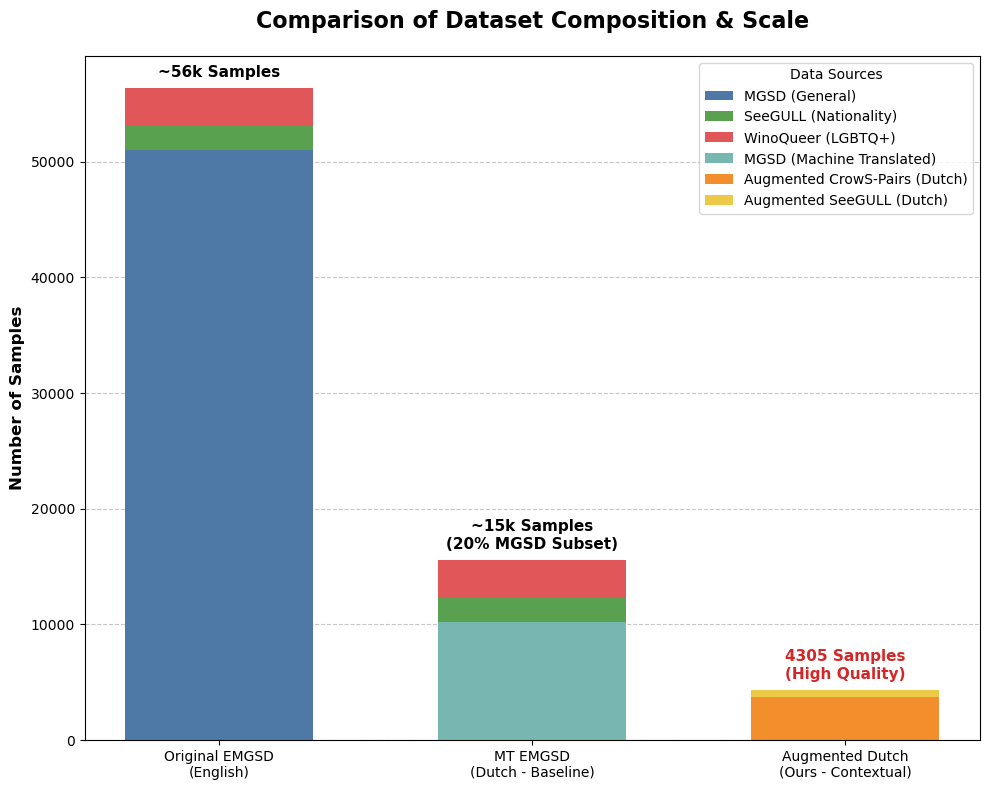

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# Data Configuration
# ==========================================
# 1. Original EMGSD
orig_mgsd = 51000
orig_wino = 3264
orig_seagull = 2070
total_orig = orig_mgsd + orig_wino + orig_seagull

# 2. Machine Translated EMGSD subset
# 20% of MGSD + Full Wino/SeeGULL
mt_mgsd = orig_mgsd * 0.20
mt_wino = orig_wino
mt_seagull = orig_seagull
total_mt = mt_mgsd + mt_wino + mt_seagull

# 3. Augmented Dutch (Your New Dataset)
# Total 4305
aug_total = 4305
aug_crows = 3747
aug_seagull = 558

# ==========================================
# Plotting
# ==========================================
# Set up the figure
fig, ax = plt.subplots(figsize=(10, 8))

# Bar Width
width = 0.6

# --- Column 1: Original EMGSD ---
p1_1 = ax.bar("Original EMGSD\n(English)", orig_mgsd, width, label='MGSD', color='#4e79a7') # Blue
p1_2 = ax.bar("Original EMGSD\n(English)", orig_seagull, width, bottom=orig_mgsd, label='SeeGULL', color='#59a14f') # Green
p1_3 = ax.bar("Original EMGSD\n(English)", orig_wino, width, bottom=orig_mgsd+orig_seagull, label='WinoQueer', color='#e15759') # Red

# --- Column 2: MT EMGSD ---
p2_1 = ax.bar("MT EMGSD\n(Dutch)", mt_mgsd, width, color='#76b7b2') # Teal (Distinct from MGSD blue)
p2_2 = ax.bar("MT EMGSD\n(Dutch)", mt_seagull, width, bottom=mt_mgsd, color='#59a14f') # Green (Same source)
p2_3 = ax.bar("MT EMGSD\n(Dutch)", mt_wino, width, bottom=mt_mgsd+mt_seagull, color='#e15759') # Red (Same source)

# --- Column 3: Augmented Dutch ---
p3_1 = ax.bar("Augmented Dutch\n(Ours - Contextual)", aug_crows, width, label='Aug. CrowS-Pairs', color='#f28e2b') # Orange
p3_2 = ax.bar("Augmented Dutch\n(Ours - Contextual)", aug_seagull, width, bottom=aug_crows, label='Aug. SeeGULL', color='#edc948') # Yellow

# --- Annotations & Styling ---
# Title and Labels
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Comparison of Dataset Composition & Scale', fontsize=16, fontweight='bold', pad=20)

# Add Total Counts on top of bars
ax.text(0, total_orig + 1000, f"~{int(total_orig/1000)}k Samples", ha='center', fontsize=11, fontweight='bold')
ax.text(1, total_mt + 1000, f"~{int(total_mt/1000)}k Samples\n(20% MGSD Subset)", ha='center', fontsize=11, fontweight='bold')
ax.text(2, aug_total + 1000, f"{aug_total} Samples\n(High Quality)", ha='center', fontsize=11, fontweight='bold', color='#d62728')

handles, labels = ax.get_legend_handles_labels()
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4e79a7', label='MGSD (MT)'),
    Patch(facecolor='#59a14f', label='SeeGULL (Nationality) (MT)'),
    Patch(facecolor='#e15759', label='WinoQueer (LGBTQ+) (MT)'),
    Patch(facecolor='#76b7b2', label='MGSD (Machine Translated)'),
    Patch(facecolor='#f28e2b', label='Augmented CrowS-Pairs (Dutch)'),
    Patch(facecolor='#edc948', label='Augmented SeeGULL (Dutch)'),
]

ax.legend(handles=legend_elements, loc='upper right', title="Data Sources", fontsize=10)

# Grid and Layout
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()

# Save
plt.savefig("Dataset_Comparison_Chart.png", dpi=300)
plt.show()

Matplotlib is building the font cache; this may take a moment.


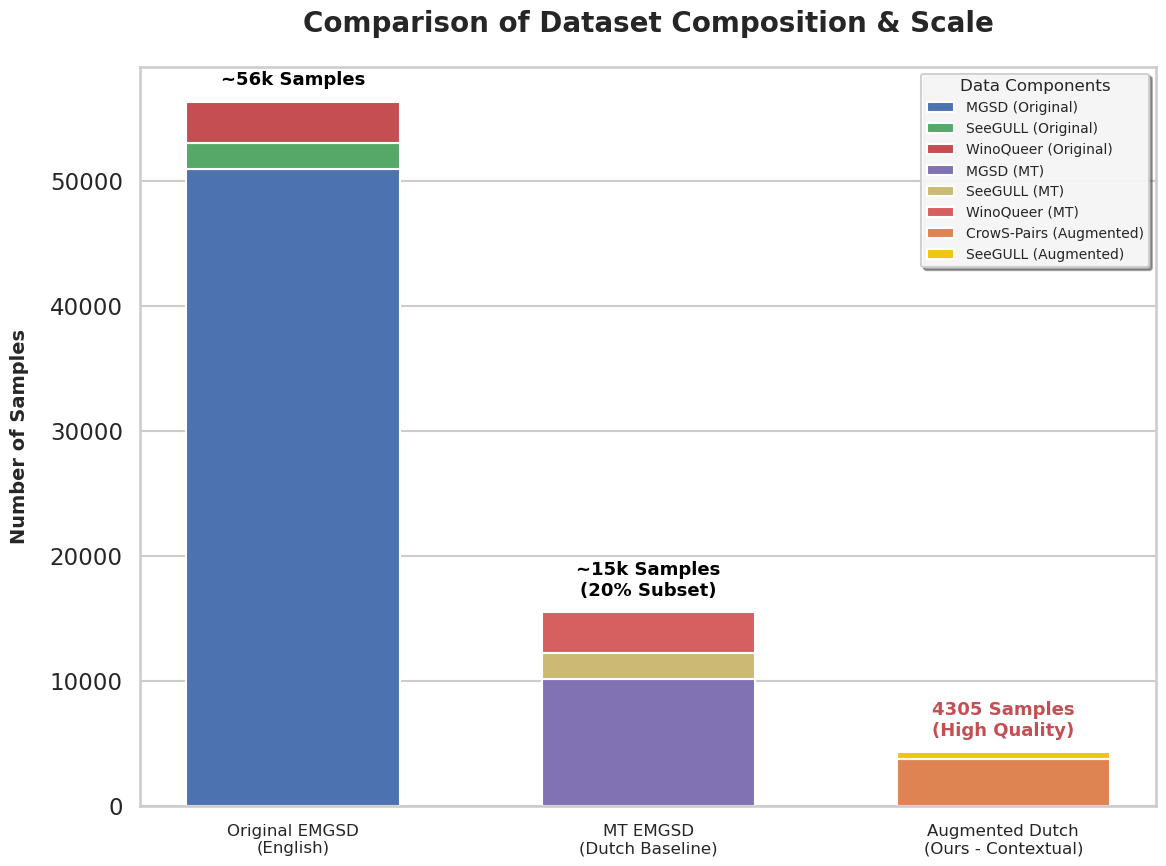

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", context="talk")

# 1. Original EMGSD (English)
orig_mgsd = 51000
orig_wino = 3264
orig_seagull = 2070
total_orig = orig_mgsd + orig_wino + orig_seagull

# 2. Machine Translated EMGSD (Dutch Baseline)
# 20% of MGSD + Full Wino/SeeGULL (MT versions)
mt_mgsd = orig_mgsd * 0.20
mt_wino = orig_wino
mt_seagull = orig_seagull
total_mt = mt_mgsd + mt_wino + mt_seagull

# 3. Augmented Dutch (Ours - Contextual)
# CrowS (Dutch) + SeeGULL (Dutch)
aug_total = 4305
aug_crows = 3747
aug_seagull = 558

# Create figure
fig, ax = plt.subplots(figsize=(12, 9))

# Bar Width & Positions
width = 0.6
x_labels = ["Original EMGSD\n(English)", "MT EMGSD\n(Dutch Baseline)", "Augmented Dutch\n(Ours - Contextual)"]
x_pos = np.arange(len(x_labels))

# --- Colors (Seaborn/Tableau derived) ---
c_mgsd = '#4c72b0'      # Deep Blue (Original MGSD)
c_seagull = '#55a868'   # Green (Original SeeGULL)
c_wino = '#c44e52'      # Red (Original WinoQueer)

c_mt_mgsd = '#8172b3'   # Purple (MT MGSD - distinct)
c_mt_seagull = '#ccb974' # Muted Yellow/Green (MT SeeGULL)
c_mt_wino = '#d65f5f'   # Light Red (MT Wino)

c_aug_crows = '#dd8452' # Orange (Augmented CrowS)
c_aug_seagull = '#f1c40f' # Bright Yellow (Augmented SeeGULL)

# --- Stacked Bar 1: Original EMGSD ---
ax.bar(0, orig_mgsd, width, label='MGSD', color=c_mgsd, edgecolor='white')
ax.bar(0, orig_seagull, width, bottom=orig_mgsd, label='SeeGULL', color=c_seagull, edgecolor='white')
ax.bar(0, orig_wino, width, bottom=orig_mgsd+orig_seagull, label='WinoQueer', color=c_wino, edgecolor='white')

# --- Stacked Bar 2: MT EMGSD ---
ax.bar(1, mt_mgsd, width, color=c_mt_mgsd, edgecolor='white')
ax.bar(1, mt_seagull, width, bottom=mt_mgsd, color=c_mt_seagull, edgecolor='white')
ax.bar(1, mt_wino, width, bottom=mt_mgsd+mt_seagull, color=c_mt_wino, edgecolor='white')

# --- Stacked Bar 3: Augmented Dutch ---
ax.bar(2, aug_crows, width, color=c_aug_crows, edgecolor='white')
ax.bar(2, aug_seagull, width, bottom=aug_crows, color=c_aug_seagull, edgecolor='white')

# Title and Axis
ax.set_ylabel('Number of Samples', fontsize=14, fontweight='bold', labelpad=15)
ax.set_title('Comparison of Dataset Composition & Scale', fontsize=20, fontweight='bold', pad=25)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=12)

# Grid cleanup (Remove vertical gridlines)
ax.grid(axis='x')

# Add Total Counts on top of bars
def add_label(x, y, text, color='black'):
    ax.text(x, y + 1000, text, ha='center', va='bottom', fontsize=13, fontweight='bold', color=color)

add_label(0, total_orig, f"~{int(total_orig/1000)}k Samples")
add_label(1, total_mt, f"~{int(total_mt/1000)}k Samples\n(20% Subset)")
add_label(2, aug_total, f"{aug_total} Samples\n(High Quality)", color='#c44e52') # Red highlight

# --- Custom Legend ---
# Grouping the legend logic for clarity
legend_elements = [
    # Group 1: Original Sources
    Patch(facecolor=c_mgsd, label='MGSD (Original)'),
    Patch(facecolor=c_seagull, label='SeeGULL (Original)'),
    Patch(facecolor=c_wino, label='WinoQueer (Original)'),

    # Group 2: Machine Translated (MT)
    Patch(facecolor=c_mt_mgsd, label='MGSD (MT)'),
    Patch(facecolor=c_mt_seagull, label='SeeGULL (MT)'),
    Patch(facecolor=c_mt_wino, label='WinoQueer (MT)'),

    # Group 3: Augmented (Ours)
    Patch(facecolor=c_aug_crows, label='CrowS-Pairs (Augmented)'),
    Patch(facecolor=c_aug_seagull, label='SeeGULL (Augmented)'),
]

# Position Legend outside or upper right
ax.legend(handles=legend_elements, loc='upper right', title="Data Components",
          fontsize=10, title_fontsize=12, frameon=True, framealpha=0.9, shadow=True)

# Adjust layout to fit everything
plt.tight_layout()

# Save and Show
plt.savefig("Dataset_Comparison_Chart_Seaborn.png", dpi=300, bbox_inches='tight')
plt.show()